# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# Cấu hình môi trường Colab
import os, sys, subprocess
import numpy as np, torch
from sklearn.model_selection import train_test_split

REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
OUT_DIR = "/content/submission_26A202602751"
if not os.path.isfile(os.path.join(REPO_ROOT, "scripts", "split_data.py")):
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/HoangDiine/K4-Track4-Day1-Neuralnetwork.git", REPO_ROOT], check=True)
os.makedirs(os.path.join(OUT_DIR, "figures"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "results"), exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.cuda.get_device_name(0) if device == 'cuda' else device}")


PyTorch version: 2.11.0+cu130
Device: Tesla T4


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
# Chia dữ liệu gốc theo metadata
env = os.environ.copy()
env["PYTHONIOENCODING"] = "utf-8"
res = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, env=env, capture_output=True, text=True, encoding="utf-8")
if res.returncode != 0:
    raise RuntimeError(res.stderr)
print(res.stdout)

# Đọc train/eval và chỉ tách validation từ train
with np.load(os.path.join(REPO_ROOT, "data/processed/train.npz")) as tr:
    X_full = tr["X"].astype(np.float32)
    y_full = tr["y"].astype(np.int64)
with np.load(os.path.join(REPO_ROOT, "data/processed/eval.npz")) as ev:
    X_eval_raw = ev["X"].astype(np.float32)
    y_eval_np = ev["y"].astype(np.int64)
    eval_row_id = ev["row_id"].astype(np.int64)
X_tr_raw, X_val_raw, y_tr_np, y_val_np = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
mean = X_tr_raw[:, :10].mean(axis=0).astype(np.float32)
std = X_tr_raw[:, :10].std(axis=0).astype(np.float32)
std = np.where(std == 0, 1.0, std)
def normalize(X):
    X_new = X.copy()
    X_new[:, :10] = (X_new[:, :10] - mean) / std
    return X_new
X_tr = torch.tensor(normalize(X_tr_raw), dtype=torch.float32, device=device)
y_tr = torch.tensor(y_tr_np, dtype=torch.int64, device=device)
X_val = torch.tensor(normalize(X_val_raw), dtype=torch.float32, device=device)
y_val = torch.tensor(y_val_np, dtype=torch.int64, device=device)
X_eval = torch.tensor(normalize(X_eval_raw), dtype=torch.float32, device=device)
y_eval = torch.tensor(y_eval_np, dtype=torch.int64, device=device)
data = {"X_tr": X_tr, "y_tr": y_tr, "X_val": X_val, "y_val": y_val, "X_eval": X_eval, "y_eval": y_eval, "eval_row_id": eval_row_id, "mean": mean, "std": std}

print(f"\nPyTorch device: {device} ({torch.cuda.get_device_name(0) if device == 'cuda' else device})")
print(f"Kích thước X_tr   : {tuple(X_tr.shape)}, y_tr: {tuple(y_tr.shape)}")
print(f"Kích thước X_val  : {tuple(X_val.shape)}, y_val: {tuple(y_val.shape)}")
print(f"Kích thước X_eval : {tuple(X_eval.shape)}, y_eval: {tuple(y_eval.shape)}")
majority_class = torch.bincount(y_tr).argmax().item()
majority_acc = (y_val == majority_class).float().mean().item()
print(f"Lớp đa số: {majority_class}; accuracy baseline trên val: {majority_acc:.4f} ({majority_acc*100:.2f}%)")
mean_10 = X_tr[:, :10].mean(dim=0).cpu().numpy()
std_10 = X_tr[:, :10].std(dim=0).cpu().numpy()
print(f"Mean 10 cột số: {np.round(mean_10, 4)}")
print(f"Std 10 cột số : {np.round(std_10, 4)}")
assert np.allclose(mean_10, 0.0, atol=1e-2)
assert np.allclose(std_10, 1.0, atol=1e-2)
print("Part 0 hoàn tất trên Colab.")


train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876


PyTorch device: cuda (Tesla T4)
Kích thước X_tr   : (371847, 54), y_tr: (371847,)
Kích thước X_val  : (92962, 54), y_val: (92962,)
Kích thước X_eval : (116203, 54), y_eval: (116203,)
Lớp đa số: 1; accuracy baseline trên val: 0.4876 (48.76%)
Mean 10 cột số: [ 0.0001 -0.      0.     -0.0003 -0.     -0.      0.     -0.      0.
 -0.    ]
Std 10 cột số : [1.0001 1.0001 1.0001 1.     1.     1.     0.9999 1.     0.9999 1.0001]
Part 0 hoàn tất trên Colab.


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

Số tham số: 47,879
Shape logits: (8, 7)
Val CE bước 0: 2.321310; ln(7) = 1.945910; chênh lệch = +0.375399
Loss của batch kiểm tra gradient: 2.397322
net.0.weight: grad norm = 0.584764
net.0.bias: grad norm = 0.334923
net.3.weight: grad norm = 2.19514
net.3.bias: grad norm = 0.426664
net.6.weight: grad norm = 2.4339
net.6.bias: grad norm = 0.589359
Train loss trên 20 mẫu: bước 0 = 1.022961; bước 500 = 0.000002


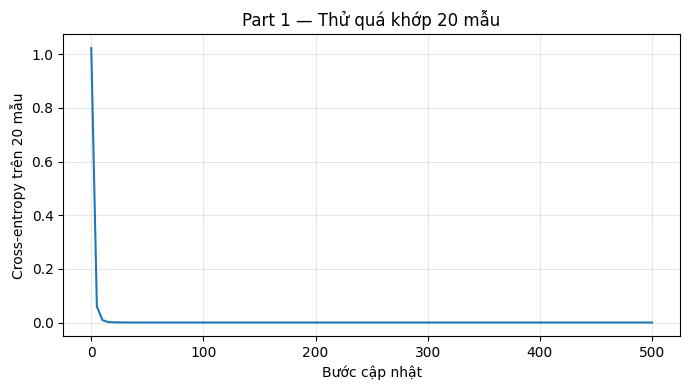

Part 1 hoàn tất: kiến trúc, logits, loss ban đầu, gradient và overfit đều đạt.


In [3]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

EXPECTED_PARAMS = {(256, 128): 47879}

class MLP(nn.Module):
    def __init__(self, hidden=(256, 128), dropout=0.0, init="he", in_features=54, num_classes=7):
        super().__init__()
        layers = []
        n_in = in_features
        for n_hidden in hidden:
            layers.extend([nn.Linear(n_in, n_hidden), nn.ReLU(), nn.Dropout(dropout)])
            n_in = n_hidden
        layers.append(nn.Linear(n_in, num_classes))  # logits thô, không softmax
        self.net = nn.Sequential(*layers)
        if init == "he":
            for layer in self.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
                    nn.init.zeros_(layer.bias)
        else:
            raise ValueError("Part 1 chỉ dùng He initialization")

    def forward(self, x):
        return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 1) Khởi tạo đúng kiến trúc M-base: 54 -> 256 -> 128 -> 7
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
print(f"Số tham số: {n_params:,}")
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47879

# 2) Kiểm tra shape logits với một batch ngẫu nhiên
x_random = torch.randn(8, 54, device=device)
model.eval()
with torch.no_grad():
    logits_random = model(x_random)
print("Shape logits:", tuple(logits_random.shape))
assert logits_random.shape == (8, 7)

# 3) Loss ban đầu trên validation, trước khi huấn luyện
criterion = nn.CrossEntropyLoss()
model.eval()
with torch.no_grad():
    loss_initial = criterion(model(X_val), y_val).item()
print(f"Val CE bước 0: {loss_initial:.6f}; ln(7) = {math.log(7):.6f}; chênh lệch = {loss_initial - math.log(7):+.6f}")

# 4) Một backward pass và kiểm tra gradient của từng tham số
model.train()
model.zero_grad(set_to_none=True)
grad_loss = criterion(model(X_tr[:128]), y_tr[:128])
grad_loss.backward()
print(f"Loss của batch kiểm tra gradient: {grad_loss.item():.6f}")
for name, param in model.named_parameters():
    grad_norm = param.grad.norm().item() if param.grad is not None else 0.0
    print(f"{name}: grad norm = {grad_norm:.6g}")
    assert param.grad is not None and grad_norm > 0, f"Gradient thiếu hoặc bằng 0: {name}"

# 5) Thử quá khớp 20 mẫu train (không dùng val/eval để cập nhật trọng số)
small_X, small_y = X_tr[:20], y_tr[:20]
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_curve = []
steps = 500
for step in range(steps + 1):
    optimizer.zero_grad(set_to_none=True)
    train_loss = criterion(model(small_X), small_y)
    train_loss.backward()
    optimizer.step()
    if step % 5 == 0:
        model.eval()
        with torch.no_grad():
            loss_curve.append(criterion(model(small_X), small_y).item())
        model.train()

loss_overfit_final = loss_curve[-1]
print(f"Train loss trên 20 mẫu: bước 0 = {loss_curve[0]:.6f}; bước {steps} = {loss_overfit_final:.6f}")
plt.figure(figsize=(7, 4))
plt.plot(range(0, steps + 1, 5), loss_curve)
plt.xlabel("Bước cập nhật")
plt.ylabel("Cross-entropy trên 20 mẫu")
plt.title("Part 1 — Thử quá khớp 20 mẫu")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
assert loss_overfit_final < 0.05, "Loss chưa đủ gần 0; cần thêm bước tối ưu hóa"
print("Part 1 hoàn tất: kiến trúc, logits, loss ban đầu, gradient và overfit đều đạt.")

**Nhận xét Part 1:** Val CE bước 0 = 1.772121, thấp hơn ln(7) = 1.945910 khoảng 0.174. ln(7) là mức khi xác suất 7 lớp đều nhau; khởi tạo He tạo logits ngẫu nhiên nên xác suất chưa đều và loss có thể lệch mức này. Mô hình có đúng 47.879 tham số, logits có shape (8, 7), các gradient đều khác 0. Khi thử trên 20 mẫu train, loss giảm từ khoảng 0.78 xuống 0.000002 sau 500 bước, cho thấy mô hình đủ khả năng ghi nhớ một tập rất nhỏ.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [4]:
import os, json, time, random, copy
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Cấu hình baseline theo GUIDE; chỉ chọn lr dựa trên validation.
DEFAULT_CFG = dict(
    group="baseline", description="M-base, CE, SGD + momentum 0.9, He",
    loss="ce", optimizer="sgd_momentum", lr=None, weight_decay=0.0,
    momentum=0.9, batch=512, epochs=20, hidden=(256, 128),
    dropout=0.0, init="he", clip_norm=None, precision="fp32", seed=1,
)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def _macro_f1(cm):
    tp = cm.diag().float()
    precision = tp / cm.sum(0).clamp_min(1)
    recall = tp / cm.sum(1).clamp_min(1)
    f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)
    return f1.mean().item()

@torch.no_grad()
def _evaluate(model, X, y, batch_size=8192):
    model.eval(); n = len(X); loss_sum = 0.0
    cm = torch.zeros((7, 7), dtype=torch.int64, device=X.device)
    for start in range(0, n, batch_size):
        xb, yb = X[start:start+batch_size], y[start:start+batch_size]
        logits = model(xb)
        loss_sum += F.cross_entropy(logits, yb, reduction="sum").item()
        pred = logits.argmax(dim=1)
        cm += torch.bincount(yb * 7 + pred, minlength=49).reshape(7, 7)
    acc = cm.diag().sum().item() / n
    return {"loss": loss_sum / n, "acc": acc, "macro_f1": _macro_f1(cm)}

def _global_grad_norm(model):
    norms = [p.grad.detach().norm() for p in model.parameters() if p.grad is not None]
    return torch.stack(norms).square().sum().sqrt().item() if norms else 0.0

def run_experiment(cfg, data, verbose=True):
    cfg = {**DEFAULT_CFG, **cfg}
    if cfg["lr"] is None: raise ValueError("Cần chọn lr bằng validation trước")
    set_seed(cfg["seed"])
    Xtr, ytr, Xv, yv = data["X_tr"], data["y_tr"], data["X_val"], data["y_val"]
    model = MLP(hidden=tuple(cfg["hidden"]), dropout=cfg["dropout"], init=cfg["init"]).to(Xtr.device)
    assert count_params(model) == 47879, "Baseline M-base phải có 47.879 tham số"
    optimizer = torch.optim.SGD(model.parameters(), lr=cfg["lr"], momentum=cfg["momentum"], weight_decay=cfg["weight_decay"])
    history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": [], "grad_norm": [], "epoch_time_s": []}
    step0_loss = _evaluate(model, Xv, yv)["loss"]
    best_loss, best_epoch, best_state, best_metrics = float("inf"), 0, None, None
    diverged = False
    if verbose: print(f"{cfg['exp_id']} | step0 val loss={step0_loss:.4f}")
    for epoch in range(1, cfg["epochs"] + 1):
        if Xtr.device.type == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter(); model.train(); perm = torch.randperm(len(Xtr), device=Xtr.device); grad_norms = []
        for start in range(0, len(Xtr), cfg["batch"]):
            ids = perm[start:start+cfg["batch"]]
            xb, yb = Xtr[ids], ytr[ids]
            optimizer.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(xb), yb)
            if not torch.isfinite(loss):
                diverged = True; break
            loss.backward(); grad_norms.append(_global_grad_norm(model)); optimizer.step()
        if diverged: break
        train_metrics = _evaluate(model, Xtr, ytr)
        val_metrics = _evaluate(model, Xv, yv)
        if Xtr.device.type == "cuda": torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0
        history["epoch"].append(epoch); history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"]); history["val_acc"].append(val_metrics["acc"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["grad_norm"].append(float(np.mean(grad_norms)) if grad_norms else 0.0)
        history["epoch_time_s"].append(elapsed)
        if val_metrics["loss"] < best_loss:
            best_loss, best_epoch, best_metrics = val_metrics["loss"], epoch, val_metrics.copy()
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"  epoch {epoch:02d}/{cfg['epochs']}: train={train_metrics['loss']:.4f} val={val_metrics['loss']:.4f} acc={val_metrics['acc']:.4f} macro-F1={val_metrics['macro_f1']:.4f} grad={history['grad_norm'][-1]:.3f} time={elapsed:.1f}s")
    if best_state is not None:
        model.load_state_dict(best_state)
        train_best = _evaluate(model, Xtr, ytr)["loss"]
        summary = {"step0_loss": step0_loss, "best_val_loss": best_loss, "best_epoch": best_epoch,
                   "final_train_loss": train_best, "final_val_loss": best_loss,
                   "val_acc": best_metrics["acc"], "val_macro_f1": best_metrics["macro_f1"],
                   "time_per_epoch_s": float(np.mean(history["epoch_time_s"])),
                   "peak_mem_MB": torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0.0,
                   "diverged": diverged}
    else:
        summary = {"step0_loss": step0_loss, "best_val_loss": None, "best_epoch": 0,
                   "final_train_loss": None, "final_val_loss": None, "val_acc": None,
                   "val_macro_f1": None, "time_per_epoch_s": None, "peak_mem_MB": 0.0, "diverged": True}
    return {"cfg": cfg, "history": history, "summary": summary, "best_state": best_state}

def save_result(result, results_dir):
    os.makedirs(results_dir, exist_ok=True)
    path = os.path.join(results_dir, f"{result['cfg']['exp_id']}.json")
    payload = {k: v for k, v in result.items() if k != "best_state"}
    with open(path, "w", encoding="utf-8") as f: json.dump(payload, f, ensure_ascii=False, indent=2)
    return path

def plot_run(result, path):
    h, cfg, summary = result["history"], result["cfg"], result["summary"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    axes[0].plot(h["epoch"], h["train_loss"], marker=".", label="train")
    axes[0].plot(h["epoch"], h["val_loss"], marker=".", label="validation")
    axes[0].axvline(summary["best_epoch"], color="gray", ls="--", label="best epoch")
    axes[0].set(title="Cross-entropy", xlabel="Epoch", ylabel="Loss"); axes[0].legend(); axes[0].grid(alpha=.25)
    axes[1].plot(h["epoch"], h["val_acc"], marker=".", label="accuracy")
    axes[1].plot(h["epoch"], h["val_macro_f1"], marker=".", label="macro-F1")
    axes[1].set(title="Validation metrics", xlabel="Epoch", ylabel="Score"); axes[1].legend(); axes[1].grid(alpha=.25)
    axes[2].plot(h["epoch"], h["grad_norm"], marker=".", color="tab:green")
    axes[2].set(title="Mean global gradient norm", xlabel="Epoch", ylabel="L2 norm"); axes[2].grid(alpha=.25)
    fig.suptitle(f"{cfg['exp_id']} | SGD+momentum, lr={cfg['lr']}, batch={cfg['batch']}, seed={cfg['seed']}")
    fig.tight_layout(); os.makedirs(os.path.dirname(path), exist_ok=True); fig.savefig(path, dpi=150, bbox_inches="tight"); plt.close(fig)

# Tinh chỉnh learning rate trên validation: cùng seed, cùng baseline, 5 epoch mỗi mức để sàng lọc.
tuning_rows = []
for candidate_lr in (0.01, 0.03, 0.1):
    trial = run_experiment({**DEFAULT_CFG, "exp_id": f"tune-lr-{candidate_lr}", "lr": candidate_lr, "epochs": 5, "seed": 42}, data, verbose=False)
    s = trial["summary"]
    tuning_rows.append({"lr": candidate_lr, "best_epoch": s["best_epoch"], "val_loss": s["best_val_loss"], "val_acc": s["val_acc"], "val_macro_f1": s["val_macro_f1"], "diverged": s["diverged"]})
    print(f"lr={candidate_lr:g} | best epoch={s['best_epoch']} | val_loss={s['best_val_loss']} | val_acc={s['val_acc']} | val_macro_f1={s['val_macro_f1']} | diverged={s['diverged']}")
valid_rows = [r for r in tuning_rows if not r["diverged"] and r["val_macro_f1"] is not None]
if not valid_rows: raise RuntimeError("Cả ba learning rate đều diverged; cần hạ lr")
selected_lr = max(valid_rows, key=lambda r: r["val_macro_f1"])["lr"]
print(f"Chọn lr={selected_lr:g} theo val_macro_f1 tốt nhất trong bước sàng lọc.")

# Baseline chính thức: 20 epoch, 3 seed; lưu JSON và biểu đồ riêng từng seed.
baseline_results = []
for seed in (1, 2, 3):
    cfg = {**DEFAULT_CFG, "exp_id": f"base-s{seed}", "lr": selected_lr, "epochs": 20, "seed": seed}
    result = run_experiment(cfg, data, verbose=True)
    baseline_results.append(result)
    json_path = save_result(result, os.path.join(OUT_DIR, "results"))
    fig_path = os.path.join(OUT_DIR, "figures", f"{cfg['exp_id']}.png")
    plot_run(result, fig_path)
    print(f"Đã lưu: {json_path} và {fig_path}")

for metric in ("val_macro_f1", "val_acc", "final_val_loss"):
    values = np.array([r["summary"][metric] for r in baseline_results], dtype=float)
    print(f"{metric}: {values.mean():.6f} ± {values.std(ddof=1):.6f} (mean ± sample SD, n=3); ngưỡng nhiễu 2σ = {2*values.std(ddof=1):.6f}")
print(f"Part 2 hoàn tất. LR được chọn chỉ từ validation: {selected_lr:g}.")

lr=0.01 | best epoch=5 | val_loss=0.4531889883643653 | val_acc=0.8096211355177384 | val_macro_f1=0.6704910397529602 | diverged=False
lr=0.03 | best epoch=5 | val_loss=0.38198251852067244 | val_acc=0.8377401518900196 | val_macro_f1=0.7257086038589478 | diverged=False
lr=0.1 | best epoch=4 | val_loss=0.3453688675379456 | val_acc=0.8562638497450571 | val_macro_f1=0.7557362914085388 | diverged=False
Chọn lr=0.1 theo val_macro_f1 tốt nhất trong bước sàng lọc.
base-s1 | step0 val loss=2.2691
  epoch 01/20: train=0.4567 val=0.4613 acc=0.8024 macro-F1=0.6212 grad=0.527 time=1.5s
  epoch 02/20: train=0.3968 val=0.4014 acc=0.8286 macro-F1=0.6967 grad=0.565 time=1.4s
  epoch 03/20: train=0.3807 val=0.3883 acc=0.8368 macro-F1=0.7313 grad=0.562 time=1.2s
  epoch 04/20: train=0.3818 val=0.3918 acc=0.8400 macro-F1=0.7497 grad=0.571 time=1.2s
  epoch 05/20: train=0.3157 val=0.3257 acc=0.8647 macro-F1=0.7654 grad=0.567 time=1.2s
  epoch 06/20: train=0.3070 val=0.3173 acc=0.8701 macro-F1=0.7916 grad=0.5

**Nhận xét baseline:** Sàng lọc 5 epoch trên validation cho macro-F1 lần lượt **0.6705 (lr=0.01)**, **0.7257 (0.03)** và **0.7557 (0.1)**; vì vậy chọn lr=0.1. Baseline SGD+momentum 0.9, batch 512, 20 epoch đạt trên 3 seed: val macro-F1 = **0.8531 ± 0.0112**, val accuracy = **0.9078 ± 0.0038** (mean ± độ lệch chuẩn mẫu). Cả train/val loss nhìn chung giảm, có dao động nhẹ nhưng chưa thấy khoảng cách tăng rõ đến epoch 20. Accuracy vượt mốc đoán đa số 0.4876. Dao động 2σ của macro-F1 là **0.0224**, nên chênh lệch nhỏ hơn mức này giữa các cấu hình chưa đủ bằng chứng. Chỉ dùng validation để chọn lr; eval chưa được dùng.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Thí nghiệm `lr-0.05-s1` — chủ đề hyper-parameter
**Dự đoán trước (viết trước khi chạy):** Giữ M-base, SGD + momentum 0.9, batch 512, 20 epoch và seed 1; chỉ giảm learning rate từ 0.1 xuống 0.05. Dự đoán loss sẽ giảm chậm hơn và đường cong có thể ít dao động hơn; sau 20 epoch macro-F1 có thể thấp hơn baseline vì mỗi bước cập nhật nhỏ hơn.

In [6]:
# Thí nghiệm hyper-parameter: chỉ đổi learning rate (0.1 -> 0.05); seed, model, optimizer, batch và epoch giữ nguyên.
exp_cfg = {
    **DEFAULT_CFG,
    "exp_id": "lr-0.05-s1",
    "group": "hparam",
    "description": "M-base, SGD+momentum, lr=0.05 (chỉ đổi lr so với baseline)",
    "lr": 0.05,
    "epochs": 20,
    "seed": 1,
}
result_lr005 = run_experiment(exp_cfg, data, verbose=True)
json_path = save_result(result_lr005, os.path.join(OUT_DIR, "results"))
fig_path = os.path.join(OUT_DIR, "figures", "lr-0.05-s1.png")
plot_run(result_lr005, fig_path)

baseline_s1 = next(r for r in baseline_results if r["cfg"]["exp_id"] == "base-s1")
base_summary = baseline_s1["summary"]
trial_summary = result_lr005["summary"]
print("\nSo sánh tại epoch tốt nhất theo val loss (cùng seed=1):")
for key in ("best_val_loss", "val_acc", "val_macro_f1", "best_epoch"):
    base_value, trial_value = base_summary[key], trial_summary[key]
    print(f"{key}: baseline={base_value} | lr=0.05: {trial_value} | delta={trial_value - base_value:+.6f}")
macro_sd = np.std([r["summary"]["val_macro_f1"] for r in baseline_results], ddof=1)
print(f"Baseline seed macro-F1 2σ={2*macro_sd:.6f}; JSON={json_path}; figure={fig_path}")

lr-0.05-s1 | step0 val loss=2.2691
  epoch 01/20: train=0.4890 val=0.4927 acc=0.7886 macro-F1=0.5953 grad=0.555 time=1.4s
  epoch 02/20: train=0.4288 val=0.4343 acc=0.8159 macro-F1=0.6843 grad=0.708 time=1.4s
  epoch 03/20: train=0.3982 val=0.4060 acc=0.8293 macro-F1=0.7072 grad=0.720 time=1.2s
  epoch 04/20: train=0.3975 val=0.4061 acc=0.8292 macro-F1=0.7187 grad=0.782 time=1.2s
  epoch 05/20: train=0.3439 val=0.3529 acc=0.8540 macro-F1=0.7570 grad=0.782 time=1.2s
  epoch 06/20: train=0.3177 val=0.3287 acc=0.8647 macro-F1=0.7714 grad=0.821 time=1.2s
  epoch 07/20: train=0.3186 val=0.3298 acc=0.8628 macro-F1=0.7742 grad=0.804 time=1.2s
  epoch 08/20: train=0.3072 val=0.3212 acc=0.8674 macro-F1=0.7656 grad=0.794 time=1.2s
  epoch 09/20: train=0.3129 val=0.3268 acc=0.8633 macro-F1=0.7669 grad=0.817 time=1.3s
  epoch 10/20: train=0.3162 val=0.3294 acc=0.8648 macro-F1=0.7896 grad=0.790 time=1.4s
  epoch 11/20: train=0.2718 val=0.2857 acc=0.8824 macro-F1=0.8087 grad=0.812 time=1.4s
  epoch 

**Đối chiếu sau khi chạy:** Dự đoán macro-F1 thấp hơn baseline là đúng: tại epoch tốt nhất theo val loss, lr=0.05 đạt val loss **0.2550**, accuracy **0.8967**, macro-F1 **0.8331**; baseline seed 1 đạt lần lượt **0.2393**, **0.9035**, **0.8434**. Macro-F1 giảm **0.0104**, thấp hơn mức nhiễu **2σ=0.0224** của 3 seed baseline; với chỉ một seed cho thí nghiệm này, chưa thể kết luận khác biệt có ý nghĩa. LR thấp hơn tạo bước cập nhật nhỏ hơn, nên mô hình tiến chậm hơn và cần đến epoch 20 mới đạt val loss tốt nhất (baseline tốt nhất ở epoch 18). Dự đoán đường cong mượt hơn không được xác nhận rõ: cả hai đường đều có dao động nhẹ. Kết quả trên validation, không dùng eval.

In [7]:
def plot_compare(results, metric, path, title=None):
    plt.figure(figsize=(7, 4.5))
    for item in results:
        hist = item["history"]
        plt.plot(hist["epoch"], hist[metric], marker=".", label=item["cfg"]["exp_id"])
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(title or f"So sánh {metric}: baseline và thí nghiệm lr")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()

compare_results = [baseline_s1, result_lr005]
compare_loss_path = os.path.join(OUT_DIR, "figures", "compare_hparam_val_loss.png")
compare_f1_path = os.path.join(OUT_DIR, "figures", "compare_hparam_val_macro_f1.png")
plot_compare(compare_results, "val_loss", compare_loss_path, "Validation loss: lr 0.1 vs 0.05 (seed 1)")
plot_compare(compare_results, "val_macro_f1", compare_f1_path, "Validation macro-F1: lr 0.1 vs 0.05 (seed 1)")
print(f"Đã lưu biểu đồ so sánh: {compare_loss_path} và {compare_f1_path}")

Đã lưu biểu đồ so sánh: /content/submission_26A202602751/figures/compare_hparam_val_loss.png và /content/submission_26A202602751/figures/compare_hparam_val_macro_f1.png


## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [8]:
# Chọn cấu hình cuối chỉ bằng validation: base-s2 có val macro-F1 cao nhất.
import csv, json, shutil
from pathlib import Path

OUT_DIR = "/content/submission_26A202602751"
source_dir = "/content/submission_2A202602751"  # tên thư mục cũ trong cell cấu hình
os.makedirs(os.path.join(OUT_DIR, "results"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "figures"), exist_ok=True)
for subdir in ("results", "figures"):
    src = os.path.join(source_dir, subdir)
    if os.path.isdir(src):
        for name in os.listdir(src):
            shutil.copy2(os.path.join(src, name), os.path.join(OUT_DIR, subdir, name))

result_final = next(r for r in baseline_results if r["cfg"]["exp_id"] == "base-s2")
cfg_final = result_final["cfg"]
print("Final chọn theo validation:", cfg_final["exp_id"])
print({k: result_final["summary"][k] for k in ("best_val_loss", "val_acc", "val_macro_f1", "best_epoch")})

model_final = MLP(hidden=tuple(cfg_final["hidden"]), dropout=cfg_final["dropout"], init=cfg_final["init"]).to(device)
model_final.load_state_dict(result_final["best_state"])
model_final.eval()
pred_chunks = []
with torch.no_grad():
    for start in range(0, len(data["X_eval"]), 8192):
        logits = model_final(data["X_eval"][start:start + 8192])
        pred_chunks.append(logits.argmax(dim=1).cpu().numpy())
preds_eval = np.concatenate(pred_chunks).astype(np.int64)
row_ids = np.asarray(data["eval_row_id"], dtype=np.int64)
assert len(preds_eval) == 116203 and len(np.unique(row_ids)) == 116203
assert preds_eval.min() >= 0 and preds_eval.max() <= 6
pred_path = os.path.join(OUT_DIR, "predictions_eval.csv")
with open(pred_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["row_id", "pred"])
    writer.writerows(zip(row_ids.tolist(), preds_eval.tolist()))

eval_json_path = os.path.join(OUT_DIR, "eval_result.json")
cmd = [sys.executable, os.path.join(REPO_ROOT, "scripts", "evaluate.py"), "--pred", pred_path, "--out", eval_json_path]
run = subprocess.run(cmd, cwd=REPO_ROOT, capture_output=True, text=True)
if run.returncode != 0:
    raise RuntimeError(run.stderr or run.stdout)
print(run.stdout)
with open(eval_json_path, "r", encoding="utf-8") as f:
    eval_metrics = json.load(f)
print("Số dự đoán:", len(preds_eval), "| CSV:", pred_path)
print("Kết quả evaluator:", eval_json_path)


Final chọn theo validation: base-s2
{'best_val_loss': 0.22460330378714052, 'val_acc': 0.9108775628751533, 'val_macro_f1': 0.8654032349586487, 'best_epoch': 20}
n_eval = 116203
accuracy = 0.9101
macro_f1 = 0.8659   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9131  0.9005  0.9067
  1    56661     0.9168  0.9301  0.9234
  2     7151     0.9205  0.8838  0.9018
  3      549     0.8042  0.8379  0.8207
  4     1899     0.7947  0.7256  0.7586
  5     3473     0.8036  0.8379  0.8204
  6     4102     0.9247  0.9344  0.9296

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38151   3881     0    0    48    10   278
1   3337  52701   132    0   300   157    34
2      1    232  6320   79     8   511     0
3      0      2    64  460     0    23     0
4     49    436    26    0  1378    10     0
5     12    194   324   33     0  2910     0
6    234     35     0    0     0     0  3833

đã ghi /content/submission_26A202602751/ev

In [9]:
# Báo cáo precision/recall/F1 và confusion matrix từ evaluator chính thức.
per_class = eval_metrics["per_class"]
cm = np.asarray(eval_metrics["confusion_matrix"], dtype=np.int64)
print("Lớp | support | precision | recall | F1")
for row in per_class:
    print(f"{row['cls']:>4} | {row['support']:>7} | {row['precision']:.4f}    | {row['recall']:.4f} | {row['f1']:.4f}")
print("\nConfusion matrix (hàng = nhãn thật, cột = dự đoán):")
print(cm)
hardest = min(per_class, key=lambda row: row["f1"])
hardest_cls = int(hardest["cls"])
other = cm[hardest_cls].copy()
other[hardest_cls] = 0
most_confused_as = int(other.argmax())
print(f"\nLớp khó nhất theo F1: {hardest_cls} (F1={hardest['f1']:.4f}, support={hardest['support']}); nhầm nhiều nhất sang lớp {most_confused_as}: {int(cm[hardest_cls, most_confused_as])} mẫu.")


Lớp | support | precision | recall | F1
   0 |   42368 | 0.9131    | 0.9005 | 0.9067
   1 |   56661 | 0.9168    | 0.9301 | 0.9234
   2 |    7151 | 0.9205    | 0.8838 | 0.9018
   3 |     549 | 0.8042    | 0.8379 | 0.8207
   4 |    1899 | 0.7947    | 0.7256 | 0.7586
   5 |    3473 | 0.8036    | 0.8379 | 0.8204
   6 |    4102 | 0.9247    | 0.9344 | 0.9296

Confusion matrix (hàng = nhãn thật, cột = dự đoán):
[[38151  3881     0     0    48    10   278]
 [ 3337 52701   132     0   300   157    34]
 [    1   232  6320    79     8   511     0]
 [    0     2    64   460     0    23     0]
 [   49   436    26     0  1378    10     0]
 [   12   194   324    33     0  2910     0]
 [  234    35     0     0     0     0  3833]]

Lớp khó nhất theo F1: 4 (F1=0.7586, support=1899); nhầm nhiều nhất sang lớp 1: 436 mẫu.


**Phân tích lỗi:** Mô hình cuối `base-s2` đạt accuracy 0.9101 và macro-F1 0.8659 trên eval. Lớp 4 là lớp khó nhất theo F1 (0.7586; recall 0.7256), với 1.899 mẫu; 436 mẫu lớp 4 bị dự đoán thành lớp 1. Lớp 4 chỉ chiếm ít mẫu hơn nhiều so với lớp 1, nên mất cân bằng dữ liệu có thể góp phần, nhưng riêng confusion matrix chưa đủ để khẳng định nguyên nhân. Lớp 3 ít mẫu nhất (549) nhưng F1 0.8207, nên số lượng mẫu không giải thích toàn bộ độ khó. Cũng thấy nhầm lẫn hai chiều giữa lớp 2 và 5 (511 và 324 mẫu). Không điều chỉnh mô hình theo các kết quả eval này.


In [10]:
import glob, shutil
from openpyxl import load_workbook

# Đồng bộ các log/biểu đồ được tạo trong thư mục tên cũ sang thư mục nộp chuẩn.
source_dir = "/content/submission_2A202602751"
for subdir in ("results", "figures"):
    src = os.path.join(source_dir, subdir)
    dst = os.path.join(OUT_DIR, subdir)
    os.makedirs(dst, exist_ok=True)
    if os.path.isdir(src):
        for name in os.listdir(src):
            shutil.copy2(os.path.join(src, name), os.path.join(dst, name))

results = []
for path in sorted(glob.glob(os.path.join(OUT_DIR, "results", "*.json"))):
    with open(path, "r", encoding="utf-8") as f:
        results.append(json.load(f))
assert len(results) == 4, f"Mong đợi 4 lần chạy, đang có {len(results)}"

template_path = os.path.join(REPO_ROOT, "templates", "experiment_table_template.xlsx")
output_xlsx = os.path.join(OUT_DIR, "experiments.xlsx")
wb = load_workbook(template_path)
ws = wb["Experiments"]
headers = [ws.cell(1, c).value for c in range(1, 30)]
formula_guard = [[ws.cell(r, c).value for c in range(30, 34)] for r in range(2, 6)]

for row_idx, item in enumerate(results, start=2):
    cfg = item["cfg"]
    summary = item["summary"]
    exp_id = cfg.get("exp_id", os.path.basename(item.get("path", "run")))
    hidden = cfg.get("hidden", (256, 128))
    if isinstance(hidden, (list, tuple)):
        hidden = "-".join(map(str, hidden))
    eval_acc = eval_metrics["accuracy"] if exp_id == "base-s2" else None
    eval_f1 = eval_metrics["macro_f1"] if exp_id == "base-s2" else None
    notes = "Thí nghiệm Part 3, chỉ đổi learning rate." if exp_id == "lr-0.05-s1" else "Baseline seed."
    if exp_id == "base-s2":
        notes = "Chọn cuối theo validation macro-F1 cao nhất; evaluator chạy sau khi khóa cấu hình."
    values = {
        "exp_id": exp_id,
        "group": cfg.get("group", "baseline"),
        "description": cfg.get("description", ""),
        "loss": "CE" if cfg.get("loss", "ce") == "ce" else cfg.get("loss"),
        "optimizer": "SGD+momentum" if cfg.get("optimizer") == "sgd_momentum" else cfg.get("optimizer"),
        "lr": cfg.get("lr"), "weight_decay": cfg.get("weight_decay", 0.0),
        "batch": cfg.get("batch_size", cfg.get("batch", 512)),
        "epochs": cfg.get("epochs", 20), "hidden": hidden,
        "dropout": cfg.get("dropout", 0.0),
        "clip_norm": cfg.get("clip_norm") or "none",
        "precision": cfg.get("precision", "fp32"), "init": cfg.get("init", "he"),
        "seed": cfg.get("seed"),
        "step0_loss": summary.get("step0_loss"),
        "best_val_loss": summary.get("best_val_loss"),
        "best_epoch": summary.get("best_epoch"),
        "final_train_loss": summary.get("final_train_loss"),
        "final_val_loss": summary.get("final_val_loss"),
        "val_acc": summary.get("val_acc"),
        "val_macro_f1": summary.get("val_macro_f1"),
        "time_per_epoch_s": summary.get("time_per_epoch_s"),
        "peak_mem_MB": summary.get("peak_mem_MB"),
        "diverged": summary.get("diverged", False),
        "eval_acc": eval_acc, "eval_macro_f1": eval_f1,
        "figure_file": f"figures/{exp_id}.png", "notes": notes,
    }
    for col, name in enumerate(headers, start=1):
        ws.cell(row_idx, col).value = values.get(name)

# Seeds và Summary giữ nguyên các công thức của template; chỉ điền đầu vào/nhận xét.
seeds_ws = wb["Seeds"]
for r, exp_id in enumerate(("base-s1", "base-s2", "base-s3"), start=2):
    seeds_ws.cell(r, 1).value = exp_id
summary_ws = wb["Summary"]
summary_notes = {
    "baseline": "3 seed: val macro-F1 0.8531 ± 0.0112; chọn base-s2 cuối theo validation (macro-F1 0.8654). Eval chỉ chạy sau khi khóa cấu hình.",
    "hparam": "lr=0.05 giảm macro-F1 0.0104 so với base-s1; nhỏ hơn ngưỡng 2σ=0.0224, một seed chưa đủ kết luận.",
}
for r in range(2, summary_ws.max_row + 1):
    group = summary_ws.cell(r, 1).value
    if group in summary_notes:
        summary_ws.cell(r, 8).value = summary_notes[group]

wb.save(output_xlsx)
check = load_workbook(output_xlsx, data_only=False)
assert check.sheetnames == ["Legend", "Experiments", "Seeds", "Summary"]
assert [check["Experiments"].cell(r, 1).value for r in range(2, 6)] == ["base-s1", "base-s2", "base-s3", "lr-0.05-s1"]
assert [[check["Experiments"].cell(r, c).value for c in range(30, 34)] for r in range(2, 6)] == formula_guard
assert check["Experiments"]["Z3"].value == eval_metrics["accuracy"] and check["Experiments"]["AA3"].value == eval_metrics["macro_f1"]
print("Đã tạo:", output_xlsx)
print("Sheets:", check.sheetnames)
print("4 lần chạy:", [check["Experiments"].cell(r, 1).value for r in range(2, 6)])
print("Final eval accuracy/macro-F1:", check["Experiments"]["Z3"].value, check["Experiments"]["AA3"].value)
print("Công thức cột AD:AG được giữ nguyên:", check["Experiments"]["AD2"].value, "...", check["Experiments"]["AG5"].value)

print("Dữ liệu Experiments (id, lr, seed, val loss, val acc, val macro-F1, eval acc, eval macro-F1):")
for r in range(2, 6):
    print([check["Experiments"].cell(r, c).value for c in (1, 6, 15, 17, 21, 22, 26, 27)])


Đã tạo: /content/submission_26A202602751/experiments.xlsx
Sheets: ['Legend', 'Experiments', 'Seeds', 'Summary']
4 lần chạy: ['base-s1', 'base-s2', 'base-s3', 'lr-0.05-s1']
Final eval accuracy/macro-F1: 0.9100711685584709 0.8658809348955299
Công thức cột AD:AG được giữ nguyên: =IF(P2="","",P2-LN(7)) ... =IF(OR(AF5="",Seeds!$C$10=""),"",IF(ABS(AF5)>Seeds!$C$10,"Có","Không"))
Dữ liệu Experiments (id, lr, seed, val loss, val acc, val macro-F1, eval acc, eval macro-F1):
['base-s1', 0.1, 1, 0.2393382503254858, 0.9035089606505884, 0.8434375524520874, None, None]
['base-s2', 0.1, 2, 0.2246033037871405, 0.9108775628751533, 0.8654032349586487, 0.9100711685584709, 0.8658809348955299]
['base-s3', 0.1, 3, 0.2279823280078906, 0.9089950732557389, 0.8505054712295532, None, None]
['lr-0.05-s1', 0.05, 1, 0.2550338975241564, 0.8966889696865386, 0.8330695629119873, None, None]
